### Notebook 13 — Feature Level Analysis

**Purpose**
- Evaluate the predictive power of individual DIP features by training models using one feature at a time
- Compare single-feature performance against the full 26-feature model
- Compare feature-group performance against the full 26-feature model

**Inputs**
- `train_feature_vectors_normalized.csv`
- `test_feature_vectors_normalized.csv`

**Execution Model**
- Load normalized feature vectors
- Train classifier using the full current feature set as the baseline
- Train classifiers using each feature individually
- Train classifiers using feature groups: Gradient-Based, Spatial, and Frequency-Domain
- Evaluate all models on the held-out test set
- Compare individual-feature and feature-group results against the full model
- Generate visual comparisons of feature-group performance versus the full model

**Outputs**
- Single-feature performance metrics: Accuracy, Precision, Recall, F1, ROC AUC
- Top-feature comparison table vs full model
- Feature-group comparison table vs full model
- Ranked feature-level results
- Feature-group performance comparison plot
- Saved CSV, JSON, and PNG summary outputs

**Expected Behavior**
- Strong features show higher standalone predictive performance
- Feature groups generally outperform individual features
- Full feature model should outperform individual features and feature groups
- Results provide insight into feature importance and feature-group contribution

---

### 🔷 Step 1 — Startup (Environment + Path Setup + Verification)

- Import required libraries for data handling, model training, evaluation, and visualization  
- Configure notebook behavior using `VERBOSE` flag  
- Clone project repository into runtime if not already available  
- Add `src/` directory to Python path for module imports  
- Import centralized configuration from `project_config.py`  
- Convert training and test dataset paths to `Path` objects  
- Define output paths for feature-level analysis results  
- Ensure output directory exists for saving results  
- Verify required input files (train and test feature vectors) are present  
- Optionally display key paths and configuration details  

---

In [1]:
# ============================================================
# Step 1: Startup (Environment + Path Setup + Verification)
# ============================================================

# ============================================
# USER CONFIGURATION — EDIT THIS SECTION ONLY
# ============================================

VERBOSE = True   # User toggle (True or False)

# ============================================
# END USER CONFIGURATION
# ============================================

import os
import sys
import warnings
from pathlib import Path

# ------------------------------------------------------------
# Core libraries for data handling, persistence, and plotting
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import json

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Machine learning model and evaluation metrics
# ------------------------------------------------------------
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Suppress warnings if not running in verbose mode
if not VERBOSE:
    warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Clone repository into runtime if not already present
# ------------------------------------------------------------
REPO_URL = "https://github.com/pgailinas/dip-ai-image-detection.git"
REPO_DIR = Path("/content/dip-ai-image-detection")

if not REPO_DIR.exists():
    print("Cloning repository...")
    os.system(f"git clone {REPO_URL} {REPO_DIR}")

# ------------------------------------------------------------
# Ensure src/ directory is available for imports
# ------------------------------------------------------------
SRC_DIR = REPO_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# ------------------------------------------------------------
# Import centralized project configuration
# ------------------------------------------------------------
from project_config import (
    TRAIN_NORMALIZED_PATH,
    TEST_NORMALIZED_PATH,
    NUM_FEATURES,
    METADATA_COLUMNS,
    AI_LABEL,
    REAL_LABEL,
)

# ------------------------------------------------------------
# Convert configuration paths to Path objects
# ------------------------------------------------------------
TRAIN_FEATURE_VECTORS_NORMALIZED_CSV = Path(TRAIN_NORMALIZED_PATH)
TEST_FEATURE_VECTORS_NORMALIZED_CSV  = Path(TEST_NORMALIZED_PATH)

# ------------------------------------------------------------
# Define output paths for this notebook
# ------------------------------------------------------------
FEATURE_LEVEL_RESULTS_CSV_PATH = REPO_DIR / "models" / "feature_level_results.csv"
FEATURE_LEVEL_RESULTS_JSON_PATH = REPO_DIR / "models" / "feature_level_results.json"

# ------------------------------------------------------------
# Ensure output directory exists
# ------------------------------------------------------------
FEATURE_LEVEL_RESULTS_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Verify required input files exist before proceeding
# ------------------------------------------------------------
print("Verifying required input files...\n")

required_files = [
    TRAIN_FEATURE_VECTORS_NORMALIZED_CSV,
    TEST_FEATURE_VECTORS_NORMALIZED_CSV
]

missing = [str(f) for f in required_files if not f.exists()]

if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

print("All required input files are present.")

# ------------------------------------------------------------
# Display key paths and configuration (optional)
# ------------------------------------------------------------
if VERBOSE:
    print(f"Train data       : {TRAIN_FEATURE_VECTORS_NORMALIZED_CSV}")
    print(f"Test data        : {TEST_FEATURE_VECTORS_NORMALIZED_CSV}")
    print(f"Results CSV      : {FEATURE_LEVEL_RESULTS_CSV_PATH}")
    print(f"Results JSON     : {FEATURE_LEVEL_RESULTS_JSON_PATH}")

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nStartup complete.")



Cloning repository...
Verifying required input files...

All required input files are present.
Train data       : /content/dip-ai-image-detection/metadata/vectors/train_feature_vectors_normalized.csv
Test data        : /content/dip-ai-image-detection/metadata/vectors/test_feature_vectors_normalized.csv
Results CSV      : /content/dip-ai-image-detection/models/feature_level_results.csv
Results JSON     : /content/dip-ai-image-detection/models/feature_level_results.json

Startup complete.


### 🔷 Step 2 — Load Normalized Feature Vectors

- Load normalized training feature vectors from CSV  
- Load normalized test feature vectors from CSV  
- Display dataset shapes when `VERBOSE` is enabled  
- Optionally preview the first few rows of each dataset  
- Confirm that both datasets were loaded successfully  

---

In [2]:
# ============================================================
# Step 2: Load Normalized Feature Vectors
# ============================================================

# ------------------------------------------------------------
# Load normalized training and test feature vectors
# ------------------------------------------------------------
df_train = pd.read_csv(TRAIN_FEATURE_VECTORS_NORMALIZED_CSV)
df_test = pd.read_csv(TEST_FEATURE_VECTORS_NORMALIZED_CSV)

# ------------------------------------------------------------
# Display dataset shapes and previews if verbose output is enabled
# ------------------------------------------------------------
if VERBOSE:
    print("Loaded normalized feature vectors.\n")
    print(f"Training data shape : {df_train.shape}")
    print(f"Test data shape     : {df_test.shape}")

    print("\nTraining data preview:")
    display(df_train.head())

    print("\nTest data preview:")
    display(df_test.head())

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nFeature vector loading complete.")



Loaded normalized feature vectors.

Training data shape : (14400, 30)
Test data shape     : (3600, 30)

Training data preview:


,filename,class_label,source_dataset,subset,Mean Gradient,Std Gradient,Max Gradient,Gradient Entropy,Edge Density,Orientation Mean,...,Noise Residual Energy,Low Frequency Energy Ratio,Mid Frequency Energy Ratio,High Frequency Energy Ratio,Radial Mean,Radial Std,Radial Entropy,Spectral Centroid,Spectral Bandwidth,Log Spectrum Std
0,rl_imgn_002320.png,rl,ImageNet_1K_256,train,0.973214,1.208264,0.913526,0.776979,0.735101,-0.207859,...,1.071297,-0.189219,0.111086,0.417247,0.448644,0.439427,-0.549996,-0.084929,0.290945,-1.254194
1,rl_coco_001397.png,rl,MS_COCO_2017,train,-0.450913,-0.225225,0.641767,-0.488332,-0.447341,-0.246587,...,-0.330229,-0.264290,0.292101,0.144170,-1.327122,-1.325683,1.397134,0.856623,0.808074,0.071118
2,rl_imgn_001958.png,rl,ImageNet_1K_256,train,0.605933,0.723094,0.717432,0.610900,0.160581,-0.468100,...,0.851489,-0.544033,0.442499,0.805334,-0.343146,-0.332461,-0.549996,-0.217414,0.432281,-1.341491
3,rl_coco_000800.png,rl,MS_COCO_2017,train,0.021388,0.357107,0.528482,-0.077406,0.331237,1.075664,...,0.188882,0.518813,-0.552523,-0.349898,1.963337,1.956027,-0.549996,-0.448685,-0.628062,-1.111831
4,ai_mj_002892.png,ai,Midjourney,train,-0.212459,-0.661686,-0.209270,0.288772,-0.061089,-0.293840,...,-0.281104,0.607047,-0.600533,-0.556607,-0.011009,-0.013482,-0.549996,-0.185376,-0.470299,0.325939



Test data preview:


,filename,class_label,source_dataset,subset,Mean Gradient,Std Gradient,Max Gradient,Gradient Entropy,Edge Density,Orientation Mean,...,Noise Residual Energy,Low Frequency Energy Ratio,Mid Frequency Energy Ratio,High Frequency Energy Ratio,Radial Mean,Radial Std,Radial Entropy,Spectral Centroid,Spectral Bandwidth,Log Spectrum Std
0,rl_coco_001786.png,rl,MS_COCO_2017,test,0.497872,-0.409551,0.681864,0.559988,0.054908,-0.305565,...,1.283031,0.072984,-0.093042,-0.000168,-0.175451,-0.167723,-0.549996,-0.387637,-0.204424,-0.898870
1,rl_coco_001292.png,rl,MS_COCO_2017,test,0.927560,0.358681,0.946748,0.880741,0.393183,-0.422829,...,1.554584,-0.319957,0.225217,0.585821,-0.240700,-0.242071,-0.549996,-0.065630,0.382678,-1.479785
2,ai_sdxl_002062.png,ai,SDXL_Generated_10K,test,-0.620579,0.043886,1.061698,-1.269570,-0.505036,-0.727340,...,-0.682819,0.625482,-0.615693,-0.583366,0.996778,1.003541,-0.549996,-0.472758,-0.712630,0.485553
3,ai_sdxl_000022.png,ai,SDXL_Generated_10K,test,0.403077,-0.557194,-1.870341,1.648585,1.121353,1.184433,...,0.828271,0.229313,-0.209054,-0.267265,-0.498871,-0.480981,-0.549996,-0.363626,-0.186430,1.645108
4,ai_diff_002198.png,ai,DiffusionDB,test,-0.126248,0.518973,0.726811,-0.540193,-0.054409,1.185280,...,0.056304,0.129764,-0.157096,-0.026978,0.060581,0.051685,-0.549996,-0.160865,-0.006949,-1.300368



Feature vector loading complete.


### 🔷 Step 3 — Separate Features and Labels

- Separate class labels from normalized feature vectors  
- Remove metadata columns from the feature matrices  
- Create training and test feature matrices  
- Create training and test label vectors  
- Store the ordered feature column list for feature-level iteration  
- Verify the number of extracted feature columns  

---

In [3]:
# ============================================================
# Step 3: Separate Features and Labels
# ============================================================

# ------------------------------------------------------------
# Separate labels from training and test datasets
# ------------------------------------------------------------
y_train = df_train["class_label"]
y_test = df_test["class_label"]

# ------------------------------------------------------------
# Remove metadata columns to isolate feature columns
# ------------------------------------------------------------
feature_columns = [
    col for col in df_train.columns
    if col not in METADATA_COLUMNS
]

# ------------------------------------------------------------
# Create training and test feature matrices
# ------------------------------------------------------------
X_train = df_train[feature_columns]
X_test = df_test[feature_columns]

# ------------------------------------------------------------
# Verify extracted feature structure
# ------------------------------------------------------------
if len(feature_columns) != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} features, but found {len(feature_columns)}."
    )

# ------------------------------------------------------------
# Display feature extraction summary if verbose output is enabled
# ------------------------------------------------------------
if VERBOSE:
    print("Separated features and labels.\n")
    print(f"Number of features : {len(feature_columns)}")
    print(f"Training features  : {X_train.shape}")
    print(f"Test features      : {X_test.shape}")
    print(f"Training labels    : {y_train.shape}")
    print(f"Test labels        : {y_test.shape}")

    print("\nFeature columns:")
    for feature in feature_columns:
        print(f"  - {feature}")

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nFeature and label separation complete.")



Separated features and labels.

Number of features : 26
Training features  : (14400, 26)
Test features      : (3600, 26)
Training labels    : (14400,)
Test labels        : (3600,)

Feature columns:
  - Mean Gradient
  - Std Gradient
  - Max Gradient
  - Gradient Entropy
  - Edge Density
  - Orientation Mean
  - Orientation Std
  - Orientation Entropy
  - Global Entropy
  - Local Entropy Mean
  - Local Entropy Std
  - Intensity Mean
  - Intensity Std
  - Laplacian Variance
  - Patch Variance Mean
  - Patch Variance Std
  - Noise Residual Energy
  - Low Frequency Energy Ratio
  - Mid Frequency Energy Ratio
  - High Frequency Energy Ratio
  - Radial Mean
  - Radial Std
  - Radial Entropy
  - Spectral Centroid
  - Spectral Bandwidth
  - Log Spectrum Std

Feature and label separation complete.


### 🔷 Step 4 — Define Evaluation Function

- Define a reusable function to train a model and evaluate performance  
- Fit the model using training data  
- Generate predictions on the test set  
- Compute evaluation metrics: Accuracy, Precision, Recall, F1 Score, ROC AUC  
- Return results in a structured dictionary for consistency  
- Ensure compatibility with both full-feature and single-feature models  

---

In [4]:
# ============================================================
# Step 4: Define Evaluation Function
# ============================================================

# ------------------------------------------------------------
# Define function to train model and compute evaluation metrics
# ------------------------------------------------------------
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Train the model and evaluate performance on test data.
    Returns a dictionary of evaluation metrics.
    """

    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------
    model.fit(X_train, y_train)

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_pred = model.predict(X_test)

    # --------------------------------------------------------
    # Generate probability scores (for ROC AUC)
    # --------------------------------------------------------
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=AI_LABEL),
        "recall": recall_score(y_test, y_pred, pos_label=AI_LABEL),
        "f1": f1_score(y_test, y_pred, pos_label=AI_LABEL),
        "roc_auc": roc_auc_score(y_test, y_prob) if y_prob is not None else None
    }

    return metrics

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("Evaluation function defined.")



Evaluation function defined.


### 🔷 Step 5 — Train Full Feature Baseline Model

- Define the full-feature baseline classifier  
- Train the model using all normalized DIP features  
- Note that training may take approximately 1 minute depending on runtime environment  
- Evaluate baseline performance on the held-out test set  
- Store full-model metrics for comparison with single-feature models  
- Display baseline results and total runtime when `VERBOSE` is enabled  

---

In [5]:
# ============================================================
# Step 5: Train Full Feature Baseline Model
# ============================================================

import time

# ------------------------------------------------------------
# Define full-feature baseline model
# ------------------------------------------------------------
full_feature_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

# ------------------------------------------------------------
# Inform user of expected runtime
# ------------------------------------------------------------
if VERBOSE:
    print("Training full-feature baseline model (this may take ~1 minute)...\n")

# ------------------------------------------------------------
# Train and evaluate model
# ------------------------------------------------------------
start_time = time.time()

full_model_metrics = evaluate_model(
    full_feature_model,
    X_train,
    y_train,
    X_test,
    y_test
)

elapsed_time = time.time() - start_time

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
if VERBOSE:
    print("Full-feature baseline model results:\n")

    for metric_name, metric_value in full_model_metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")

    print(f"\nTotal runtime: {elapsed_time:.2f} seconds")

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nFull-feature baseline evaluation complete.")



Training full-feature baseline model (this may take ~1 minute)...

Full-feature baseline model results:

accuracy: 0.7547
precision: 0.7348
recall: 0.7972
f1: 0.7647
roc_auc: 0.8348

Total runtime: 54.33 seconds

Full-feature baseline evaluation complete.


### 🔷 Step 6 — Train Single-Feature Models

- Train one classifier per DIP feature using only that feature as input  
- Evaluate each single-feature model on the held-out test set  
- Store feature name and performance metrics for comparison  
- Display progress when `VERBOSE` is enabled  
- Preserve the same model configuration used for the full-feature baseline  
- Training may take a few minutes  

---

In [6]:
# ============================================================
# Step 6: Train Single-Feature Models
# ============================================================

import time

# ------------------------------------------------------------
# Initialize list to store single-feature evaluation results
# ------------------------------------------------------------
single_feature_results = []

# ------------------------------------------------------------
# Inform user of expected runtime (always shown)
# ------------------------------------------------------------
total_features = len(feature_columns)

print(f"Training {total_features} single-feature models (this may take a few minutes)...\n")

start_time = time.time()

# ------------------------------------------------------------
# Train and evaluate one model per feature
# ------------------------------------------------------------
for idx, feature_name in enumerate(feature_columns, start=1):

    if VERBOSE:
        print(f"[{idx}/{total_features}] Evaluating feature: {feature_name}")

    # --------------------------------------------------------
    # Extract single feature
    # --------------------------------------------------------
    X_train_single = X_train[[feature_name]]
    X_test_single = X_test[[feature_name]]

    # --------------------------------------------------------
    # Define model (same as baseline)
    # --------------------------------------------------------
    single_feature_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        batch_size=32,
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    )

    # --------------------------------------------------------
    # Train and evaluate
    # --------------------------------------------------------
    feature_metrics = evaluate_model(
        single_feature_model,
        X_train_single,
        y_train,
        X_test_single,
        y_test
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    single_feature_results.append({
        "feature_name": feature_name,
        **feature_metrics
    })

# ------------------------------------------------------------
# Completion summary
# ------------------------------------------------------------
elapsed_time = time.time() - start_time

print(f"\nCompleted single-feature training in {elapsed_time:.2f} seconds.")



Training 26 single-feature models (this may take a few minutes)...

[1/26] Evaluating feature: Mean Gradient
[2/26] Evaluating feature: Std Gradient
[3/26] Evaluating feature: Max Gradient
[4/26] Evaluating feature: Gradient Entropy
[5/26] Evaluating feature: Edge Density
[6/26] Evaluating feature: Orientation Mean
[7/26] Evaluating feature: Orientation Std
[8/26] Evaluating feature: Orientation Entropy
[9/26] Evaluating feature: Global Entropy
[10/26] Evaluating feature: Local Entropy Mean
[11/26] Evaluating feature: Local Entropy Std
[12/26] Evaluating feature: Intensity Mean
[13/26] Evaluating feature: Intensity Std
[14/26] Evaluating feature: Laplacian Variance
[15/26] Evaluating feature: Patch Variance Mean
[16/26] Evaluating feature: Patch Variance Std
[17/26] Evaluating feature: Noise Residual Energy
[18/26] Evaluating feature: Low Frequency Energy Ratio
[19/26] Evaluating feature: Mid Frequency Energy Ratio
[20/26] Evaluating feature: High Frequency Energy Ratio
[21/26] Evaluat

### 🔷 Step 7 — Aggregate Results into DataFrame

- Convert single-feature evaluation results into a DataFrame  
- Sort features by ROC AUC in descending order  
- Reset row indexing after sorting  
- Display the ranked feature-level results when `VERBOSE` is enabled  

---

In [7]:
# ============================================================
# Step 7: Aggregate Results into DataFrame
# ============================================================

# ------------------------------------------------------------
# Convert single-feature results into DataFrame
# ------------------------------------------------------------
df_feature_results = pd.DataFrame(single_feature_results)

# ------------------------------------------------------------
# Sort feature results by ROC AUC
# ------------------------------------------------------------
df_feature_results = df_feature_results.sort_values(
    by="roc_auc",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Display ranked feature results if verbose output is enabled
# ------------------------------------------------------------
if VERBOSE:
    print("Ranked single-feature performance results:\n")
    display(df_feature_results)

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nFeature-level results aggregation complete.")



Ranked single-feature performance results:



,feature_name,accuracy,precision,recall,f1,roc_auc
0,Laplacian Variance,0.655556,0.653509,0.662222,0.657837,0.705844
1,High Frequency Energy Ratio,0.642222,0.658416,0.591111,0.622951,0.692229
2,Log Spectrum Std,0.645000,0.624049,0.729444,0.672643,0.688749
3,Noise Residual Energy,0.634444,0.648831,0.586111,0.615879,0.679390
4,Max Gradient,0.630556,0.649112,0.568333,0.606043,0.678165
5,Low Frequency Energy Ratio,0.625278,0.649042,0.545556,0.592816,0.669111
6,Std Gradient,0.629444,0.654101,0.549444,0.597222,0.661898
7,Mid Frequency Energy Ratio,0.622500,0.645353,0.543889,0.590292,0.660638
8,Mean Gradient,0.611389,0.619416,0.577778,0.597873,0.649458
9,Spectral Bandwidth,0.609167,0.620923,0.560556,0.589197,0.646169



Feature-level results aggregation complete.


### 🔷 Step 8 — Compare Top Features Against Full Model

- Select top N single features based on ROC AUC  
- Display full-feature baseline values in the metric headings  
- Show single-feature metric values below each corresponding full-model reference  
- Provide a compact comparison without repeating the same full-model values in every row  
- Display results when `VERBOSE` is enabled  

---

In [8]:
# ============================================================
# Step 8: Compare Top Features Against Full Model
# ============================================================

# ------------------------------------------------------------
# Select top N features based on ROC AUC
# ------------------------------------------------------------
TOP_N = 5
df_top_n = df_feature_results.head(TOP_N).copy()

# ------------------------------------------------------------
# Build compact comparison table
# ------------------------------------------------------------
df_comparison = pd.DataFrame({
    "Feature": df_top_n["feature_name"],
    f"Accuracy (F={full_model_metrics['accuracy']:.4f})": df_top_n["accuracy"],
    f"Precision (F={full_model_metrics['precision']:.4f})": df_top_n["precision"],
    f"Recall (F={full_model_metrics['recall']:.4f})": df_top_n["recall"],
    f"F1 (F={full_model_metrics['f1']:.4f})": df_top_n["f1"],
    f"ROC AUC (F={full_model_metrics['roc_auc']:.4f})": df_top_n["roc_auc"],
})

# ------------------------------------------------------------
# Display centered table if verbose output is enabled
# ------------------------------------------------------------
if VERBOSE:
    print(f"Top {TOP_N} single-feature results vs full-feature baseline:\n")

    display(
        df_comparison.style
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]}
        ])
    )

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nTop feature comparison complete.")



Top 5 single-feature results vs full-feature baseline:



,Feature,Accuracy (F=0.7547),Precision (F=0.7348),Recall (F=0.7972),F1 (F=0.7647),ROC AUC (F=0.8348)
0,Laplacian Variance,0.655556,0.653509,0.662222,0.657837,0.705844
1,High Frequency Energy Ratio,0.642222,0.658416,0.591111,0.622951,0.692229
2,Log Spectrum Std,0.645000,0.624049,0.729444,0.672643,0.688749
3,Noise Residual Energy,0.634444,0.648831,0.586111,0.615879,0.679390
4,Max Gradient,0.630556,0.649112,0.568333,0.606043,0.678165



Top feature comparison complete.


### 🔷 Step 9 — Feature Group Comparison Against Full Model

- Group features into Gradient-Based, Spatial, and Frequency-Domain categories    
- Train a classifier using each feature group independently  
- Evaluate group-level performance on the held-out test set  
- Compare each group’s performance against the full-feature model  
- Display full-model reference values in the table headings  
- Show progress and runtime information during execution  

---

In [9]:
# ============================================================
# Step 9: Feature Group Comparison Against Full Model
# ============================================================

import time

# ------------------------------------------------------------
# Define feature groups for current 26-feature implementation
# ------------------------------------------------------------
gradient_features = [
    "Mean Gradient",
    "Std Gradient",
    "Max Gradient",
    "Gradient Entropy",
    "Edge Density",
    "Orientation Mean",
    "Orientation Std",
    "Orientation Entropy"
]

spatial_features = [
    "Global Entropy",
    "Local Entropy Mean",
    "Local Entropy Std",
    "Intensity Mean",
    "Intensity Std",
    "Laplacian Variance",
    "Patch Variance Mean",
    "Patch Variance Std",
    "Noise Residual Energy"
]

frequency_features = [
    "Low Frequency Energy Ratio",
    "Mid Frequency Energy Ratio",
    "High Frequency Energy Ratio",
    "Radial Mean",
    "Radial Std",
    "Radial Entropy",
    "Spectral Centroid",
    "Spectral Bandwidth",
    "Log Spectrum Std"
]

feature_groups = {
    "Gradient-Based": gradient_features,
    "Spatial": spatial_features,
    "Frequency-Domain": frequency_features
}

# ------------------------------------------------------------
# Evaluate each feature group
# ------------------------------------------------------------
group_results = []
total_groups = len(feature_groups)

print(
    f"Training {total_groups} feature-group models "
    "(this may take a few minutes)...\n"
)

start_time = time.time()

for idx, (group_name, features) in enumerate(feature_groups.items(), start=1):

    if VERBOSE:
        print(f"[{idx}/{total_groups}] Evaluating group: {group_name}")
        print(f"    Number of features: {len(features)}")

    group_start_time = time.time()

    # --------------------------------------------------------
    # Select feature subset for current group
    # --------------------------------------------------------
    X_train_group = X_train[features]
    X_test_group = X_test[features]

    # --------------------------------------------------------
    # Define group-level model using baseline configuration
    # --------------------------------------------------------
    group_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        batch_size=32,
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    )

    # --------------------------------------------------------
    # Train and evaluate group-level model
    # --------------------------------------------------------
    group_metrics = evaluate_model(
        group_model,
        X_train_group,
        y_train,
        X_test_group,
        y_test
    )

    elapsed_group_time = time.time() - group_start_time

    if VERBOSE:
        print(f"    Complete in {elapsed_group_time:.2f} seconds")
        print(f"    ROC AUC: {group_metrics['roc_auc']:.4f}")
        print(f"    F1     : {group_metrics['f1']:.4f}\n")

    # --------------------------------------------------------
    # Store group-level results
    # --------------------------------------------------------
    group_results.append({
        "feature_group": group_name,
        "num_features": len(features),
        **group_metrics
    })

# ------------------------------------------------------------
# Convert group results to DataFrame
# ------------------------------------------------------------
df_group_results = pd.DataFrame(group_results)

# ------------------------------------------------------------
# Build compact group comparison table
# Full-feature baseline values are included in column headings
# ------------------------------------------------------------
df_group_comparison = pd.DataFrame({
    "Feature Group": df_group_results["feature_group"],
    "Num Features": df_group_results["num_features"],
    f"Accuracy (F={full_model_metrics['accuracy']:.4f})": df_group_results["accuracy"],
    f"Precision (F={full_model_metrics['precision']:.4f})": df_group_results["precision"],
    f"Recall (F={full_model_metrics['recall']:.4f})": df_group_results["recall"],
    f"F1 (F={full_model_metrics['f1']:.4f})": df_group_results["f1"],
    f"ROC AUC (F={full_model_metrics['roc_auc']:.4f})": df_group_results["roc_auc"],
})

# ------------------------------------------------------------
# Display group comparison results
# ------------------------------------------------------------
if VERBOSE:
    total_elapsed_time = time.time() - start_time

    print("Feature Group Performance vs Full Model:\n")

    display(
        df_group_comparison.style
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]}
        ])
    )

    print(f"\nTotal group comparison time: {total_elapsed_time:.2f} seconds")

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nFeature group comparison complete.")



Training 3 feature-group models (this may take a few minutes)...

[1/3] Evaluating group: Gradient-Based
    Number of features: 8
    Complete in 338.88 seconds
    ROC AUC: 0.6582
    F1     : 0.6043

[2/3] Evaluating group: Spatial
    Number of features: 9
    Complete in 250.47 seconds
    ROC AUC: 0.7718
    F1     : 0.7022

[3/3] Evaluating group: Frequency-Domain
    Number of features: 9
    Complete in 325.57 seconds
    ROC AUC: 0.7330
    F1     : 0.6692

Feature Group Performance vs Full Model:



,Feature Group,Num Features,Accuracy (F=0.7547),Precision (F=0.7348),Recall (F=0.7972),F1 (F=0.7647),ROC AUC (F=0.8348)
0,Gradient-Based,8,0.612500,0.617391,0.591667,0.604255,0.658225
1,Spatial,9,0.697500,0.691438,0.713333,0.702215,0.771777
2,Frequency-Domain,9,0.666111,0.663032,0.675556,0.669235,0.733047



Total group comparison time: 914.92 seconds

Feature group comparison complete.


### 🔷 Step 10 — Feature Group vs. Full Model Performance

- Compare classification performance across individual DIP feature groups and the combined full feature model
- Evaluate Gradient-Based, Spatial, Frequency-Domain, and Full Model configurations
- Visualize Accuracy, Precision, Recall, F1 Score, and ROC AUC using a grouped bar chart
- Highlight the performance improvement achieved by combining all feature groups
- Save the generated comparison figure as a high-resolution PNG file for reporting and documentation

---

Saved plot to: metadata/results/feature_group_vs_full_model.png


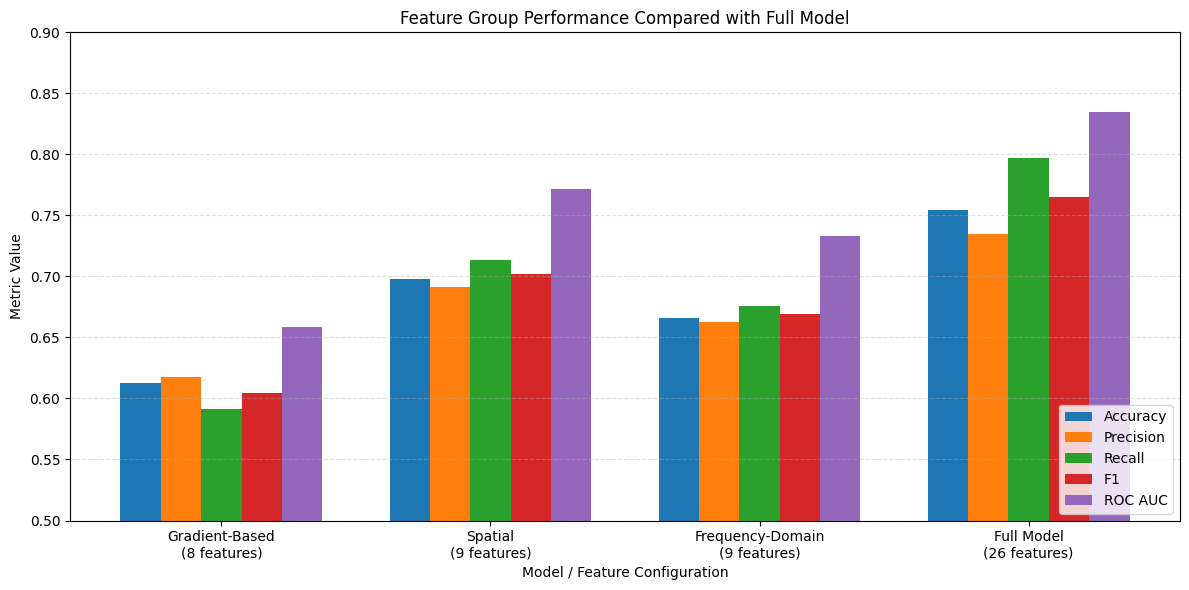

In [15]:
# ============================================
# Step 10: Feature Group vs. Full Model Performance
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Define model performance results
# -------------------------------------------------
results_df = pd.DataFrame({
    "Model": [
        "Gradient-Based\n(8 features)",
        "Spatial\n(9 features)",
        "Frequency-Domain\n(9 features)",
        "Full Model\n(26 features)"
    ],
    "Accuracy": [0.612500, 0.697500, 0.666111, 0.7547],
    "Precision": [0.617391, 0.691438, 0.663032, 0.7348],
    "Recall": [0.591667, 0.713333, 0.675556, 0.7972],
    "F1": [0.604255, 0.702215, 0.669235, 0.7647],
    "ROC AUC": [0.658225, 0.771777, 0.733047, 0.8348]
})

# -------------------------------------------------
# Configure grouped bar chart
# -------------------------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]

x = np.arange(len(results_df["Model"]))
bar_width = 0.15

plt.figure(figsize=(12, 6))

# -------------------------------------------------
# Plot one bar group per metric
# -------------------------------------------------
for i, metric in enumerate(metrics):
    offsets = x + (i - len(metrics) / 2) * bar_width + bar_width / 2

    plt.bar(
        offsets,
        results_df[metric],
        width=bar_width,
        label=metric
    )

# -------------------------------------------------
# Format plot
# -------------------------------------------------
plt.title("Feature Group Performance Compared with Full Model")
plt.xlabel("Model / Feature Configuration")
plt.ylabel("Metric Value")

plt.xticks(x, results_df["Model"])

plt.ylim(0.5, 0.9)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(loc="lower right")

plt.tight_layout()

# -------------------------------------------------
# Save figure as PNG
# -------------------------------------------------
output_dir = "metadata/results"

os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "feature_group_vs_full_model.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved plot to: {output_path}")

# -------------------------------------------------
# Display plot
# -------------------------------------------------
plt.show()



### 🔷 Step 11 — Visualization

- Create a bar chart showing single-feature ROC AUC performance  
- Sort features from strongest to weakest for readability  
- Add a reference line for the full-feature baseline ROC AUC  
- Rotate feature labels for improved display  
- Show the plot only after feature-level results have been computed  

---

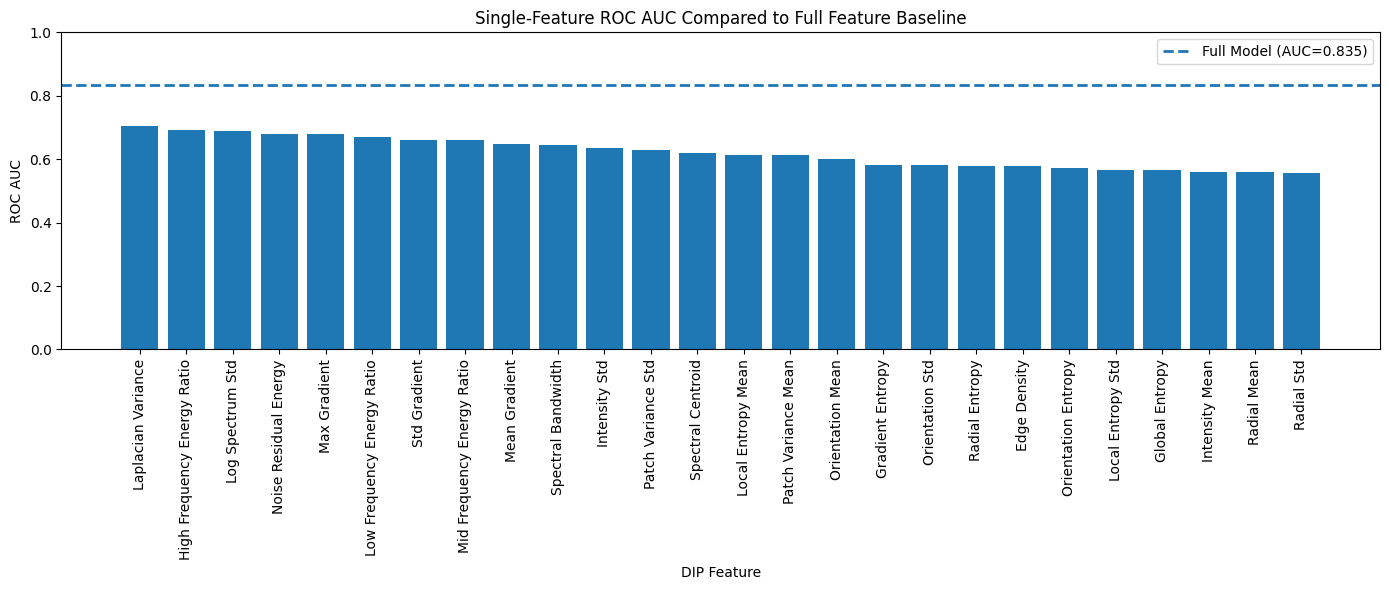


Feature-level visualization complete.


In [11]:
# ============================================================
# Step 11: Visualization
# ============================================================

# ------------------------------------------------------------
# Create bar chart of single-feature ROC AUC values
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.bar(
    df_feature_results["feature_name"],
    df_feature_results["roc_auc"]
)

# ------------------------------------------------------------
# Add full-feature baseline reference line
# ------------------------------------------------------------
plt.axhline(
    y=full_model_metrics["roc_auc"],
    linestyle="--",
    linewidth=2,
    label=f"Full Model (AUC={full_model_metrics['roc_auc']:.3f})"
)

# ------------------------------------------------------------
# Configure plot formatting
# ------------------------------------------------------------
plt.title("Single-Feature ROC AUC Compared to Full Feature Baseline")
plt.xlabel("DIP Feature")
plt.ylabel("ROC AUC")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

# ------------------------------------------------------------
# Display plot
# ------------------------------------------------------------
plt.show()

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nFeature-level visualization complete.")



### 🔷 Step 12 — Save Results

- Save full single-feature evaluation results to CSV  
- Save top-N single-feature comparison results to CSV  
- Save feature-group comparison results to CSV  
- Save full-model metrics and summary outputs to JSON  
- Preserve outputs for later reporting, tutorial pages, and final analysis  
- Display saved output paths when `VERBOSE` is enabled  

---

In [12]:
# ============================================================
# Step 12: Save Results
# ============================================================

# ------------------------------------------------------------
# Define additional output paths for notebook-specific summaries
# ------------------------------------------------------------
TOP_FEATURE_COMPARISON_CSV_PATH = (
    FEATURE_LEVEL_RESULTS_CSV_PATH.parent / "top_feature_comparison.csv"
)

FEATURE_GROUP_COMPARISON_CSV_PATH = (
    FEATURE_LEVEL_RESULTS_CSV_PATH.parent / "feature_group_comparison.csv"
)

# ------------------------------------------------------------
# Save full single-feature results table
# ------------------------------------------------------------
df_feature_results.to_csv(FEATURE_LEVEL_RESULTS_CSV_PATH, index=False)

# ------------------------------------------------------------
# Save top-N feature comparison table
# ------------------------------------------------------------
df_comparison.to_csv(TOP_FEATURE_COMPARISON_CSV_PATH, index=False)

# ------------------------------------------------------------
# Save feature-group comparison table
# ------------------------------------------------------------
df_group_comparison.to_csv(FEATURE_GROUP_COMPARISON_CSV_PATH, index=False)

# ------------------------------------------------------------
# Prepare summary output for JSON export
# ------------------------------------------------------------
feature_level_summary = {
    "full_model_metrics": full_model_metrics,
    "top_features_by_auc": df_top_n.to_dict(orient="records"),
    "feature_group_results": df_group_results.to_dict(orient="records")
}

# ------------------------------------------------------------
# Save summary output to JSON
# ------------------------------------------------------------
with open(FEATURE_LEVEL_RESULTS_JSON_PATH, "w") as f:
    json.dump(feature_level_summary, f, indent=4)

# ------------------------------------------------------------
# Display saved output paths if verbose output is enabled
# ------------------------------------------------------------
if VERBOSE:
    print("Saved feature-level analysis outputs:\n")
    print(f"Full feature results CSV     : {FEATURE_LEVEL_RESULTS_CSV_PATH}")
    print(f"Top feature comparison CSV   : {TOP_FEATURE_COMPARISON_CSV_PATH}")
    print(f"Feature group comparison CSV : {FEATURE_GROUP_COMPARISON_CSV_PATH}")
    print(f"Summary JSON                 : {FEATURE_LEVEL_RESULTS_JSON_PATH}")

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nFeature-level results saved.")



Saved feature-level analysis outputs:

Full feature results CSV     : /content/dip-ai-image-detection/models/feature_level_results.csv
Top feature comparison CSV   : /content/dip-ai-image-detection/models/top_feature_comparison.csv
Feature group comparison CSV : /content/dip-ai-image-detection/models/feature_group_comparison.csv
Summary JSON                 : /content/dip-ai-image-detection/models/feature_level_results.json

Feature-level results saved.


### 🔷 Step 13 — Key Findings Summary

- Summarize the strongest individual features based on ROC AUC  
- Summarize the weakest individual features  
- Highlight the performance gap between single-feature models and the full-feature model  
- Provide high-level observations about feature effectiveness  
- Present concise, report-ready insights  

---

In [13]:
# ============================================================
# Step 13: Key Findings Summary
# ============================================================

# ------------------------------------------------------------
# Identify top and bottom features
# ------------------------------------------------------------
top_feature = df_top_n.iloc[0]
bottom_feature = df_feature_results.iloc[-1]

# ------------------------------------------------------------
# Display key findings if verbose output is enabled
# ------------------------------------------------------------
if VERBOSE:
    print("Key Findings Summary:\n")

    print("Top Performing Feature:")
    print(f"  Feature   : {top_feature['feature_name']}")
    print(f"  ROC AUC   : {top_feature['roc_auc']:.4f}")
    print(f"  F1 Score  : {top_feature['f1']:.4f}\n")

    print("Lowest Performing Feature:")
    print(f"  Feature   : {bottom_feature['feature_name']}")
    print(f"  ROC AUC   : {bottom_feature['roc_auc']:.4f}")
    print(f"  F1 Score  : {bottom_feature['f1']:.4f}\n")

    print("Full Model Performance:")
    print(f"  ROC AUC   : {full_model_metrics['roc_auc']:.4f}")
    print(f"  F1 Score  : {full_model_metrics['f1']:.4f}\n")

    print("Observations:")
    print("  - Individual features provide varying predictive strength.")
    print("  - The full feature model outperforms any single feature.")
    print("  - Feature diversity contributes to improved classification performance.")

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nFeature-level analysis summary complete.")



Key Findings Summary:

Top Performing Feature:
  Feature   : Laplacian Variance
  ROC AUC   : 0.7058
  F1 Score  : 0.6578

Lowest Performing Feature:
  Feature   : Radial Std
  ROC AUC   : 0.5580
  F1 Score  : 0.5879

Full Model Performance:
  ROC AUC   : 0.8348
  F1 Score  : 0.7647

Observations:
  - Individual features provide varying predictive strength.
  - The full feature model outperforms any single feature.
  - Feature diversity contributes to improved classification performance.

Feature-level analysis summary complete.
